# Réseaux de neuronnes

Un réseau de neurones est un modèle d’apprentissage automatique inspiré du fonctionnement du cerveau humain. Il est composé de couches de neurones artificiels qui transforment progressivement les données d’entrée pour produire une prédiction. Chaque neurone applique une combinaison linéaire des variables suivie d’une fonction non linéaire, ce qui permet au modèle de capturer des relations complexes entre les données.

Dans le cadre de ce projet, les réseaux de neurones peuvent être particulièrement intéressants car ils sont capables de modéliser des dynamiques non linéaires et des interactions complexes entre les variables, notamment dans des séries temporelles comme les données hydrologiques ou météorologiques. Contrairement aux méthodes d’interpolation classiques ou aux approches comme le KNN, ils peuvent apprendre des motifs plus globaux et exploiter simultanément plusieurs variables explicatives. Cela peut permettre d’obtenir des imputations plus précises, en particulier lorsque les données présentent des comportements complexes ou peu réguliers.

## Imports & Variables

In [1]:
import os
import sys
import gc

sys.path.append(os.path.abspath("../../../"))

from src.methodes import *
from src.visualisations import *
from src.data import *

from keras.models import load_model




In [2]:
valeur_de_travail = 'niveau_nappe_eau'
window_size = 120

racine = "../../../"

#fichier_nappe = racine + "data/fusion/data_03288X0042_P.csv"
fichier_nappe = racine + "data/fusion/data_03276X0009_P.csv"
# dossier_nappe = racine + "data/clusterisation/inertielle"
# dossier_nappe = racine + "data/clusterisation/reactive"
dossier_nappe = racine + "data/fusion"

dossier_model = racine + "models/"

fichier_scaler = racine + "scaler/scaler.save"

features = ["niveau_nappe_eau","lon","lat","time_num","ETP_Q","PRELIQ_Q","T_Q","surface_imp","surface_totale"]

df = charger_fichier(fichier_nappe)

df['time_num'] = df['time'].astype('int64') // 10**9

df.sort_values(by='time_num', ascending=True)

,time,code_bss,niveau_nappe_eau,lon,lat,ETP_Q,PRELIQ_Q,T_Q,surface_imp,surface_totale,time_num
0,1966-01-01,03276X0009/P,108.620000,48.097518,1.923468,NaN,3.196774,NaN,195993.9444,1.912486e+07,-126231
1,1966-02-01,03276X0009/P,108.894000,48.097518,1.923468,NaN,3.889286,NaN,195993.9444,1.912486e+07,-123552
2,1966-03-01,03276X0009/P,109.290000,48.097518,1.923468,NaN,0.541935,NaN,195993.9444,1.912486e+07,-121133
3,1966-04-01,03276X0009/P,109.448000,48.097518,1.923468,NaN,2.186667,NaN,195993.9444,1.912486e+07,-118455
4,1966-05-01,03276X0009/P,109.772000,48.097518,1.923468,NaN,1.335484,NaN,195993.9444,1.912486e+07,-115863
...,...,...,...,...,...,...,...,...,...,...,...
718,2025-11-01,03276X0009/P,110.141333,48.097518,1.923468,NaN,2.376667,7.9,197102.2037,1.912486e+07,1761955
719,2025-12-01,03276X0009/P,110.097419,48.097518,1.923468,NaN,2.490323,5.6,197102.2037,1.912486e+07,1764547
720,2026-01-01,03276X0009/P,110.104839,48.097518,1.923468,NaN,1.377419,4.6,197102.2037,1.912486e+07,1767225
721,2026-02-01,03276X0009/P,110.086429,48.097518,1.923468,NaN,4.928571,8.6,197102.2037,1.912486e+07,1769904


## Préparation des données

In [3]:
#X_train, X_val, y_train, y_val, scaler = train_data_cnn(charger_dossier(dossier_nappe), window_size, fichier_scaler, croissant=True, saine=True)
X_train, X_val, y_train, y_val, scaler = train_data_variation(charger_dossier(dossier_nappe), window_size, fichier_scaler, croissant=True, saine=True)

6        0.000000
7        0.047500
16       0.508500
17       0.056500
19       0.105000
           ...   
27005   -0.006129
27006   -0.005000
27007   -0.006935
27008   -0.017398
27009   -0.004860
Name: niveau_nappe_eau, Length: 20242, dtype: float64
6       -0.000270
7       -0.000198
16       0.000498
17      -0.000185
19      -0.000112
           ...   
27005   -0.000279
27006   -0.000278
27007   -0.000281
27008   -0.000297
27009   -0.000278
Name: niveau_nappe_eau, Length: 20242, dtype: float64


## CNN

Un réseau de neurones convolutif (CNN) est un modèle conçu pour extraire automatiquement des motifs locaux dans les données à l’aide de filtres de convolution. Bien qu’il soit souvent utilisé pour les images, il peut également être appliqué à des séries temporelles. Dans ce cas, le CNN permet de détecter des patterns locaux, comme des variations rapides ou des structures répétitives dans les données. Dans ce projet, il peut être utile pour capter des comportements locaux dans les séries temporelles et améliorer l’imputation en identifiant des tendances fines difficiles à modéliser avec des méthodes classiques.

In [4]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect() 

cnn(X_train, y_train, X_val, y_val, dossier_model)

torch.cuda.empty_cache()
torch.cuda.ipc_collect() 
gc.collect()

c:\Users\tronn\Documents\STAGE-Junon\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\tronn\Documents\STAGE-Junon\venv\Lib\site-packages\keras\src\backend\torch\core.py:236: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return torch.as_tensor(x, dtype=dtype, device=get_device())


Epoch 1/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 169s 181ms/step - loss: 0.0259 - mae: 0.1035 - val_loss: 0.0245 - val_mae: 0.0944
Epoch 2/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 163s 174ms/step - loss: 0.0088 - mae: 0.0636 - val_loss: 0.0201 - val_mae: 0.0842
Epoch 3/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 163s 175ms/step - loss: 0.0055 - mae: 0.0499 - val_loss: 0.0191 - val_mae: 0.0754
Epoch 4/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 155s 165ms/step - loss: 0.0037 - mae: 0.0405 - val_loss: 0.0190 - val_mae: 0.0720
Epoch 5/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 191s 204ms/step - loss: 0.0028 - mae: 0.0353 - val_loss: 0.0180 - val_mae: 0.0664
Epoch 6/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 200s 215ms/step - loss: 0.0023 - mae: 0.0316 - val_loss: 0.0170 - val_mae: 0.0615
Epoch 7/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 202s 217ms/step - loss: 0.0022 - mae: 0.0305 - val_loss: 0.0225 - val_mae: 0.0733
Epoch 8/50
933/933 ━━━━━━━━━━━━━━━━━━━━ 218s 234ms/step - loss: 0.0018 - mae: 0.0276 - val_loss: 0.0252 - val_mae: 0.0725
Epoch 9/50
933/933 ━━━━━

21289

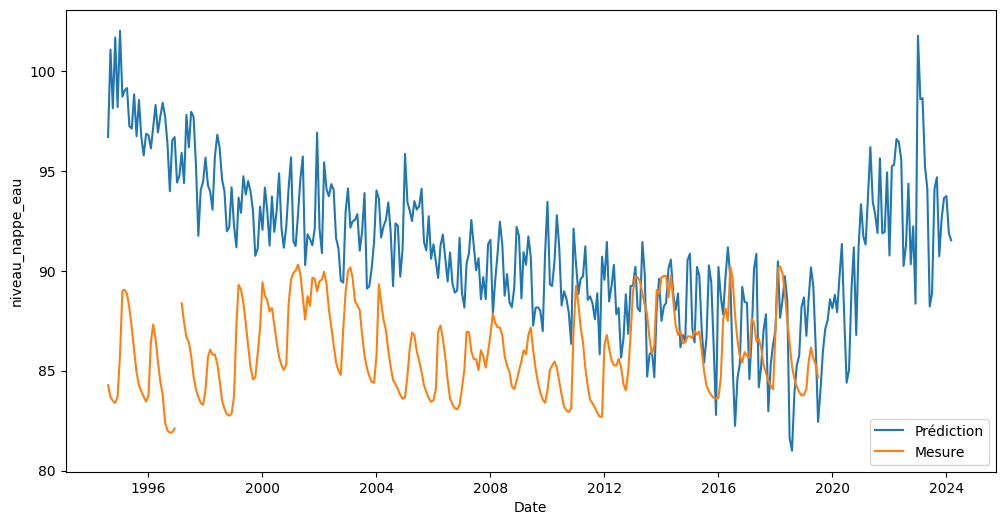

Epoch 1/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - loss: 0.0267 - mae: 0.1043
Epoch 2/1000
 1/11 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 0.0174 - mae: 0.0933

c:\Users\tronn\Documents\STAGE-Junon\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
c:\Users\tronn\Documents\STAGE-Junon\venv\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 797ms/step - loss: 0.0117 - mae: 0.0748
Epoch 3/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 944ms/step - loss: 0.0056 - mae: 0.0528
Epoch 4/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 588ms/step - loss: 0.0035 - mae: 0.0421
Epoch 5/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - loss: 0.0026 - mae: 0.0364
Epoch 6/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - loss: 0.0022 - mae: 0.0331
Epoch 7/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - loss: 0.0019 - mae: 0.0306
Epoch 8/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 761ms/step - loss: 0.0016 - mae: 0.0284
Epoch 9/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 547ms/step - loss: 0.0015 - mae: 0.0271
Epoch 10/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - loss: 0.0014 - mae: 0.0261
Epoch 11/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - loss: 0.0013 - mae: 0.0253
Epoch 12/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 578ms/step - loss: 0.0012 - mae: 0.0243
Epoch 13/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 0.0011 - mae: 0.0237
Epoch 14/1000
11

In [4]:
features = ["niveau_nappe_eau","lon","lat","time_num","ETP_Q","PRELIQ_Q","T_Q","surface_imp","surface_totale"]

valeur_de_travail = 'niveau_nappe_eau'

model_cnn = load_model(dossier_model + "CNN.keras")

mon_scaler = joblib.load(fichier_scaler)

df['time_num'] = df['time'].astype('int64') // 10**9

df.sort_values(by='time_num', ascending=True)

affiche_prediction(df.copy(), cnn_predict_array(df, model_cnn, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail), valeur_de_travail)

X_train, X_val, y_train, y_val, scaler = train_data_cnn(df.copy(), window_size, fichier_scaler, scaler=mon_scaler, croissant=False, saine=True)

callback = EarlyStopping(monitor='val_loss',
                                 patience=10,
                                 restore_best_weights=True)

model_cnn.fit(
    X_train, y_train, 
    epochs=1000, 
    batch_size=10, 
    validation_data=(X_val, y_val),
    callbacks=[callback],
    verbose=1
)

In [5]:
affiche_prediction(df.copy(), cnn_predict_array(df, model_cnn, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail), valeur_de_travail)

NameError: name 'model_cnn' is not defined

## LSTM

Le LSTM est un type de réseau de neurones récurrent (RNN) spécialement conçu pour traiter des données séquentielles. Il est capable de mémoriser des informations sur de longues périodes grâce à un mécanisme de mémoire interne. Cela le rend particulièrement adapté aux séries temporelles, où les valeurs passées influencent les valeurs futures. Dans ce projet, le LSTM permet de modéliser les dépendances temporelles et les dynamiques à long terme des données, ce qui est essentiel pour reconstruire des valeurs manquantes de manière cohérente dans le temps.

In [6]:
lstm(X_train, y_train, X_val, y_val, dossier_model)

c:\Users\tronn\Documents\STAGE-Junon\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 29s 765ms/step - loss: 0.1538 - val_loss: 0.2074
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 746ms/step - loss: 0.1073 - val_loss: 0.1575
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 762ms/step - loss: 0.0887 - val_loss: 0.1253
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 762ms/step - loss: 0.0651 - val_loss: 0.0993
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.0530 - val_loss: 0.0934
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 32s 868ms/step - loss: 0.0482 - val_loss: 0.0882
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - loss: 0.0449 - val_loss: 0.0832
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - loss: 0.0423 - val_loss: 0.0773
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - loss: 0.0400 - val_loss: 0.0714
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.0380 - val_loss: 0.0662
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 31s 828ms/step - loss: 0.0363 - val_loss: 0.0611
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 36s 977ms/step - 

## BILSTM

Le BiLSTM est une extension du LSTM qui traite les données dans les deux sens : du passé vers le futur, mais aussi du futur vers le passé. Cela permet au modèle de prendre en compte l’ensemble du contexte temporel pour chaque point. Dans le cadre de l’imputation de données, cela est particulièrement intéressant car la valeur manquante peut dépendre à la fois des observations précédentes et suivantes. Le BiLSTM permet ainsi d’obtenir des reconstructions souvent plus précises, en exploitant davantage d’information que les modèles unidirectionnels.

In [7]:
bilstm(X_train, y_train, X_val, y_val, dossier_model)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - loss: 0.1487 - val_loss: 0.1408
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - loss: 0.0936 - val_loss: 0.1128
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - loss: 0.0792 - val_loss: 0.0912
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - loss: 0.0456 - val_loss: 0.0656
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - loss: 0.0378 - val_loss: 0.0630
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - loss: 0.0350 - val_loss: 0.0583
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - loss: 0.0333 - val_loss: 0.0545
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - loss: 0.0317 - val_loss: 0.0541
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - loss: 0.0304 - val_loss: 0.0520
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - loss: 0.0294 - val_loss: 0.0493
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - loss: 0.0284 - val_loss: 0.0472
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - loss: 0.0

## Resultat

Chargement des modèles...


c:\Users\tronn\Documents\STAGE-Junon\venv\Lib\site-packages\keras\src\backend\torch\core.py:236: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return torch.as_tensor(x, dtype=dtype, device=get_device())


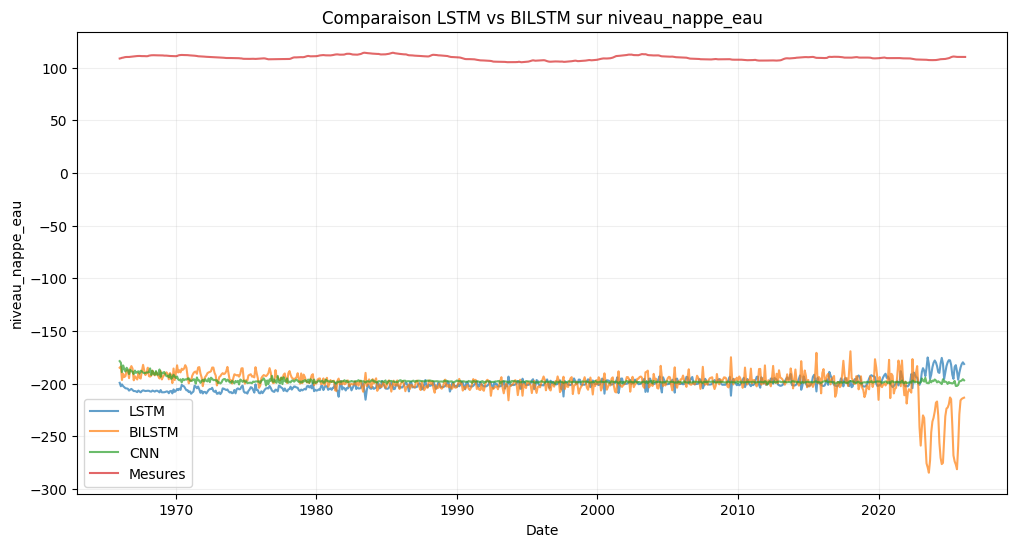

In [ ]:
features = ["niveau_nappe_eau","lon","lat","time_num","ETP_Q","PRELIQ_Q","T_Q","surface_imp","surface_totale"]

# 2. Chargement des modèles avec la perte masquée
print("Chargement des modèles...")

valeur_de_travail = "niveau_nappe_eau"

df['time_num'] = df['time'].astype('int64') // 10**9

df.sort_values(by='time_num', ascending=False)

custom_objs = {'masked_mse': masked_mse}
model_cnn = load_model(dossier_model + "CNN.keras", custom_objects={'masked_mse': masked_mse})
model_bilstm = load_model(dossier_model + "BILSTM.keras", custom_objects={'masked_mse': masked_mse})
model_lstm = load_model(dossier_model + "LSTM.keras", custom_objects={'masked_mse': masked_mse})

mon_scaler = joblib.load(fichier_scaler)
arr_lstm = cnn_predict_array(df, model_lstm, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)
arr_bilstm = cnn_predict_array(df, model_bilstm, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)
arr_cnn = cnn_predict_array(df, model_cnn, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)

methods = {
    "LSTM": arr_lstm,
    "BILSTM": arr_bilstm,
    "CNN": arr_cnn,
    "Mesures": df[valeur_de_travail],
}

# 5. Graphique
plt.figure(figsize=(12,6))
for label, arr in methods.items():
    plt.plot(df['time'], arr, label=label, alpha=0.7)

plt.title(f"Comparaison LSTM vs BILSTM sur {valeur_de_travail}")
plt.xlabel("Date")
plt.ylabel(valeur_de_travail)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Ré entrenement

In [3]:


torch.cuda.empty_cache()
torch.cuda.ipc_collect() 
gc.collect()

X_train, X_val, y_train, y_val, scaler = train_data_cnn(charger_dossier(dossier_nappe), window_size, fichier_scaler, croissant=True, saine=True)

fit(model_cnn, X_train, y_train, X_val, y_val)

torch.cuda.empty_cache()
torch.cuda.ipc_collect() 
gc.collect()

X_train, X_val, y_train, y_val, scaler = train_data(df.copy(), window_size, fichier_scaler, croissant=True)
fit(model_bilstm, X_train, y_train, X_val, y_val)

torch.cuda.empty_cache()
torch.cuda.ipc_collect() 
gc.collect()
fit(model_lstm, X_train, y_train, X_val, y_val)


mon_scaler = joblib.load(fichier_scaler)
arr_lstm = lstm_predict_array(df, model_lstm, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)
arr_bilstm = lstm_predict_array(df, model_bilstm, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)
arr_cnn = cnn_predict_array(df, model_cnn, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)

methods = {
    "LSTM": arr_lstm,
    "BILSTM": arr_bilstm,
    "CNN": arr_cnn,
    "Mesures": df[valeur_de_travail],
}

# 5. Graphique
plt.figure(figsize=(12,6))
for label, arr in methods.items():
    plt.plot(df['time'], arr, label=label, alpha=0.7)

plt.title(f"Comparaison LSTM vs BILSTM sur {valeur_de_travail}")
plt.xlabel("Date")
plt.ylabel(valeur_de_travail)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

NameError: name 'model_cnn' is not defined

## Grid search

In [ ]:
best_model, best_config, results = grid_search_all(
    X_train, y_train, X_val, y_val,
    n_workers=4  # ajuste selon ton GPU
)

best_model.save("best_model.keras")